In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO


## importing the reference sequences fetched from UniProt (UP000002473_11622.fasta)

In [3]:
records = list(SeqIO.parse('UP000002473_11622_LASV_Josiah_reference.fasta', 'fasta'))

for r in records:
    print(r.id, len(r.seq))

sp|O09705|L_LASSJ 2218
sp|O73557|Z_LASSJ 99
sp|P08669|GLYC_LASSJ 491
sp|P13699|NCAP_LASSJ 569


In [4]:
reference_by_protein = {
    "polymerase": str(next(r.seq for r in records if "O09705" in r.id)),
    "glycoprotein": str(next(r.seq for r in records if "P08669" in r.id)),
    "nucleoprotein": str(next(r.seq for r in records if "P13699" in r.id)),
    "z protein": str(next(r.seq for r in records if "O73557" in r.id)),
}

## import PairwiseAligner and use BLOSUM62 matrix for local protein alignment

In [5]:
from Bio.Align import PairwiseAligner
from Bio.Align import substitution_matrices

aligner = PairwiseAligner()
aligner.mode = 'local' #want the peptide to find its best location within the reference

aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

## choose glycoprotein

In [6]:
ref = reference_by_protein['glycoprotein']

## define mapping function

In [7]:
def map_peptide_to_reference(peptide, reference, aligner):
    """
    goal: map a peptide onto a reference protein. 

    output: returns a dictionary containing
    - alignment score
    - reference start/end (1-based)
    - reference positions covered by aligned peptide residues
    """

    #if no exact substring match, use local alignment
    alignment = aligner.align(reference, peptide)[0] #[0] to extract the first and best-scoring Alignment object from the results

    #aligner.align[0].aligned returns the start and end coordinates of the aligned segments for the target and query sequences
    ref_blocks, peptide_blocks = alignment.aligned

    ref_positions = []

    for (ref_start, ref_end), (pep_start, pep_end) in zip(ref_blocks, peptide_blocks):
        
        for i in range(ref_end - ref_start):
            ref_positions.append(ref_start + i + 1) #1-based

    #overall peptide coordinates
    pep_start = peptide_blocks[0][0] + 1
    pep_end = peptide_blocks[-1][1] #take the last block,so -1, in case there are more than one aligned blocks. and [1] for the end

    #total number of peptide residues included in the aligned blocks
    aligned_length = sum(end - start for start, end in peptide_blocks)

    #total number 

    return{
        'score': alignment.score, 
        'ref_start': ref_positions[0],
        'ref_end': ref_positions[-1],
        'ref_positions': ref_positions, 
        'pep_start' : pep_start, 
        'pep_end': pep_end,
        'aligned_length': aligned_length
    }


## set your peptides

In [8]:
unique_gp_peptides = ['TSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYMDRQGK', 'YWYLNHTTTGKTSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEM']

In [9]:
mapping = []

for peptide in unique_gp_peptides:
    result = map_peptide_to_reference(peptide, ref, aligner)

    mapping.append({
        'sequence': peptide, 
        'score': result['score'], 
        'ref_start': result['ref_start'], 
        'ref_end': result['ref_end'], 
        'ref_positions': result['ref_positions'], 
        'pep_start': result['pep_start'], 
        'pep_end': result['pep_end'], 
        'aligned_pep_length': result['aligned_length']

    })

np_mapping = pd.DataFrame(mapping)

In [10]:
np_mapping.sort_values('aligned_pep_length').head(2)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length
0,TSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYMDRQGK,243.0,380,425,"[380, 381, 382, 383, 384, 385, 386, 387, 388, ...",1,46,46
1,YWYLNHTTTGKTSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEM,255.0,369,414,"[369, 370, 371, 372, 373, 374, 375, 376, 377, ...",1,46,46


## plot aligned regions

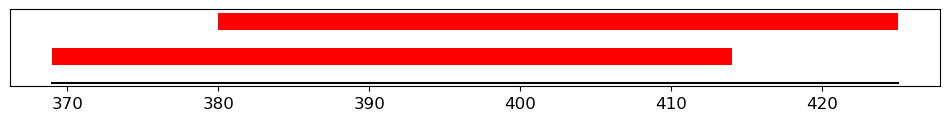

In [56]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plot_df = np_mapping.sort_values('ref_start').copy()

lf2350 = plot_df.iloc[0]
soromba = plot_df.iloc[1]

ref_start = 369
ref_end = 425

fig, ax = plt.subplots(figsize=(12, 1))

ax.plot([ref_start, ref_end], [0, 0], color='black')

peptides = [
    ('LF2350 tile 17', lf2350, 0.01), ('Soromba-R tile 19', soromba, 0.03)
]
for label, row, y in peptides: 

    start = row['ref_start']
    end = row['ref_end']

    ax.add_patch(Rectangle(
        (start, y), 
        end - start, 
        0.01,
        facecolor='red',
        linewidth=1
    ))


ax.get_yaxis().set_visible(False)
ax.tick_params(axis='x', labelsize=12)

plt.savefig('peptides_on_gp2_aa_residues.svg', format='svg')